# Computation vs Accuracy 

Single-profile version (no fast/slow split).

- RMSE curve: virtual downsampling (1..100 Hz) of each pose sequence and trajectory reconstruction error against the 200 Hz reference output.
- Power curve: estimated from measured CPU/GPU telemetry using mean latency and mean busy/idle power levels.


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('/home/moveEnetFlow/csv_file/moveEnetOFK_test/op0.005_np0.1_fp0.001')
POSE_FILES = sorted([p for p in BASE.glob('cam2_S1_*.csv') if p.is_file()])
GPU_FILES = sorted((BASE / 'gpu_monitor').glob('*.csv'))
CPU_FILES = sorted((BASE / 'powerjoular').glob('*.csv'))
FREQS_HZ = np.array([1, 5, 10, 15, 20, 30, 50, 80, 100], dtype=float)
print(f'Pose files: {len(POSE_FILES)} | CPU logs: {len(CPU_FILES)} | GPU logs: {len(GPU_FILES)}')


Pose files: 15 | CPU logs: 15 | GPU logs: 15


In [6]:
def load_pose(path: Path):
    df = pd.read_csv(path)
    t = df['timestamp'].to_numpy(dtype=float)
    joint_cols = [c for c in df.columns if c.startswith('joint')]
    joints = df[joint_cols].to_numpy(dtype=float).reshape(-1, 13, 2)
    lat = df['latency'].to_numpy(dtype=float)
    return t, joints, lat

def virtual_downsample_rmse(t_ref, joints_ref, freq_hz):
    period = 1.0 / float(freq_hz)
    t_sample = np.arange(t_ref[0], t_ref[-1] + 1e-12, period)
    if len(t_sample) < 2:
        return np.nan
    idx = np.searchsorted(t_ref, t_sample, side="left")
    idx = np.clip(idx, 0, len(t_ref) - 1)
    t_sel = t_ref[idx]
    joints_sel = joints_ref[idx]

    rec = np.empty_like(joints_ref)
    for j in range(joints_ref.shape[1]):
        for xy in range(2):
            rec[:, j, xy] = np.interp(t_ref, t_sel, joints_sel[:, j, xy])

    err = rec - joints_ref
    return np.sqrt(np.mean(err ** 2))

def rmse_frequency_curve(files, freqs_hz):
    all_rmse = []
    all_lat = []
    for path in files:
        t, joints, lat = load_pose(path)
        all_lat.append(lat)
        all_rmse.append([virtual_downsample_rmse(t, joints, f) for f in freqs_hz])
    all_rmse = np.array(all_rmse, dtype=float)
    all_lat = np.concatenate(all_lat)
    return np.nanmean(all_rmse, axis=0), float(np.mean(all_lat))

def load_cpu_power_values(cpu_files):
    vals = []
    for p in cpu_files:
        df = pd.read_csv(p)
        v = pd.to_numeric(df['CPU Power'], errors='coerce').to_numpy(dtype=float)
        v = v[np.isfinite(v)]
        vals.append(v)
    return np.concatenate(vals) if vals else np.array([], dtype=float)

def load_gpu_power_values(gpu_files):
    vals = []
    for p in gpu_files:
        df = pd.read_csv(p)
        col = [c for c in df.columns if 'power.draw' in c.lower()][0]
        v = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
        v = v[np.isfinite(v)]
        vals.append(v)
    return np.concatenate(vals) if vals else np.array([], dtype=float)

def power_model(freqs_hz, lat_s, cpu_vals, gpu_vals):
    duty = np.clip(freqs_hz * lat_s, 0.0, 1.0)
    cpu_nz = cpu_vals[cpu_vals > 0] if len(cpu_vals) else cpu_vals
    cpu_idle = float(np.percentile(cpu_nz, 10)) if len(cpu_nz) else 0.0
    cpu_busy = float(np.percentile(cpu_nz, 90)) if len(cpu_nz) else 0.0
    gpu_idle = float(np.percentile(gpu_vals, 10)) if len(gpu_vals) else 0.0
    gpu_busy = float(np.percentile(gpu_vals, 90)) if len(gpu_vals) else 0.0
    cpu_only = cpu_idle + (cpu_busy - cpu_idle) * duty
    cpu_gpu = cpu_only + gpu_idle + (gpu_busy - gpu_idle) * duty
    return cpu_only, cpu_gpu


In [7]:
rmse_curve, mean_latency_s = rmse_frequency_curve(POSE_FILES, FREQS_HZ)
cpu_vals = load_cpu_power_values(CPU_FILES)
gpu_vals = load_gpu_power_values(GPU_FILES)
cpu_only, cpu_gpu = power_model(FREQS_HZ, mean_latency_s, cpu_vals, gpu_vals)
print(f'Mean latency used for duty-cycle model: {mean_latency_s * 1000:.2f} ms')


Mean latency used for duty-cycle model: 7.16 ms


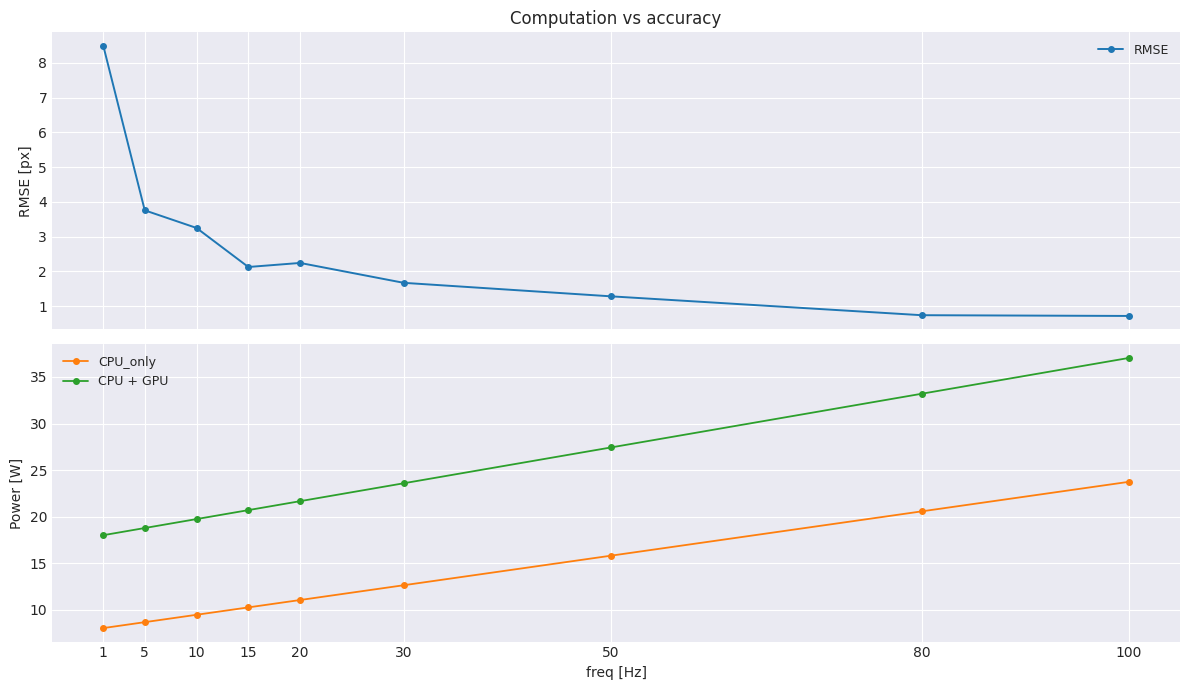

In [8]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(FREQS_HZ, rmse_curve, '-o', linewidth=1.4, markersize=4, color='tab:blue', label='RMSE')
ax1.set_title('Computation vs accuracy')
ax1.set_ylabel('RMSE [px]')
ax1.legend(loc="best", fontsize=9)

ax2.plot(FREQS_HZ, cpu_only, '-o', linewidth=1.3, markersize=4, color='tab:orange', label='CPU_only')
ax2.plot(FREQS_HZ, cpu_gpu, '-o', linewidth=1.3, markersize=4, color='tab:green', label='CPU + GPU')
ax2.set_ylabel('Power [W]')
ax2.set_xlabel('freq [Hz]')
ax2.legend(loc="best", fontsize=9)

for ax in (ax1, ax2):
    ax.set_xticks(FREQS_HZ)

fig.tight_layout()
plt.show()
